In [2]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [3]:
import scanpy as sc

# Load your dataset
adata_4i = sc.read_h5ad("4i/8h.h5ad")

# Basic overview
print(adata_4i)
print("Shape:", adata_4i.shape)

# View column names (metadata about each cell)
print("Observation columns:", adata_4i.obs.columns.tolist()[:10])
print("Feature columns:", adata_4i.var_names[:10].tolist())

# How many drugs (conditions)?
print("Unique conditions:", adata_4i.obs['drug'].unique())
print("Number of cells per condition:")
print(adata_4i.obs['drug'].value_counts())



AnnData object with n_obs × n_vars = 119479 × 78
    obs: 'drug'
    var: 'cell_part', 'measurement', 'stat', 'feature', 'original'
    uns: 'source'
Shape: (119479, 78)
Observation columns: ['drug']
Feature columns: ['morphology-nuclei-area', 'morphology-nuclei-circularity', 'morphology-nuclei-convexity', 'morphology-nuclei-eccentricity', 'morphology-nuclei-elongation', 'morphology-nuclei-equivalent_diameter', 'morphology-nuclei-extent', 'morphology-nuclei-major_axis_length', 'morphology-nuclei-mean_radius', 'morphology-nuclei-perimeter']
Unique conditions: ['ixazomib', 'everolimus', 'olaparib', 'paclitaxel', 'vemurafenib_cobimetinib', ..., 'ixazomib_lenalidomide_dexamethasone', 'melphalan', 'ulixertinib', 'dasatinib', 'sec.abcl']
Length: 38
Categories (38, object): ['cisplatin', 'cisplatin_olaparib', 'cl', 'control', ..., 'trametinib_panobinostat', 'ulixertinib', 'vemurafenib_cobimetinib', 'vindesine']
Number of cells per condition:
cl                                        18332
con

In [4]:
features_4i = [
    "intensity-cell-CD45-mean",
    "intensity-cell-ClCasp3-mean",
    "intensity-cell-DAPI-sum",
    "intensity-cell-Ki67-mean",
    "intensity-cell-MelA-mean",
    "intensity-cell-PCNA-mean",
    "intensity-cell-Sox9-mean",
    "intensity-cell-aTUB-mean",
    "intensity-cell-pAKT-mean",
    "intensity-cell-pEGFR-mean",
    "intensity-cell-pERK-mean",
    "intensity-cell-pMET-mean",
    "intensity-cell-pS6k1-mean",
    "intensity-nuclei-CD45-mean",
    "intensity-nuclei-ClCasp3-mean",
    "intensity-nuclei-DAPI-sum",
    "intensity-nuclei-Ki67-mean",
    "intensity-nuclei-MelA-mean",
    "intensity-nuclei-PCNA-mean",
    "intensity-nuclei-Sox9-mean",
    "intensity-nuclei-aTUB-mean",
    "intensity-nuclei-pAKT-mean",
    "intensity-nuclei-pEGFR-mean",
    "intensity-nuclei-pERK-mean",
    "intensity-nuclei-pMET-mean",
    "intensity-nuclei-pS6k1-mean",
    "morphology-cell-area",
    "morphology-cell-circularity",
    "morphology-cell-convexity",
    "morphology-cell-eccentricity",
    "morphology-cell-elongation",
    "morphology-cell-equivalent_diameter",
    "morphology-cell-extent",
    "morphology-cell-major_axis_length",
    "morphology-cell-mean_radius",
    "morphology-cell-perimeter",
    "morphology-cell-roundness",
    "morphology-nuclei-area",
    "morphology-nuclei-circularity",
    "morphology-nuclei-convexity",
    "morphology-nuclei-eccentricity",
    "morphology-nuclei-elongation",
    "morphology-nuclei-equivalent_diameter",
    "morphology-nuclei-extent",
    "morphology-nuclei-major_axis_length",
    "morphology-nuclei-mean_radius",
    "morphology-nuclei-perimeter",
    "morphology-nuclei-roundness"
]


In [5]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [6]:
def AOT(
    X_tr_pre, Y_tr_post, X_te_pre, Y_te_post,
    n_epochs=3000, batch_size=2048, lr=1e-3, device="auto", seed=12345, verbose=True
):
    import torch, numpy as np, random, ot
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import StandardScaler

    # ---------------- Device check ---------------- #
    if device == "auto":
        device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    
    # Helper: only pin memory for CPU→CUDA pipeline
    def should_pin(device, tensor):
        return (device.startswith("mps") and tensor.device.type == "cpu")

    # ---------------- Helper Functions ---------------- #
    def cost_matrix(X, Y):
        X2 = (X**2).sum(1, keepdims=True)
        Y2 = (Y**2).sum(1, keepdims=True).T
        return X2 + Y2 - 2 * X @ Y.T

    def exact_ot_plan(X, Y):
        a, b = torch.ones(len(X)), torch.ones(len(Y))
        C = cost_matrix(X, Y)
        Pi = ot.emd(a, b, C)
        return Pi, C

    class Mapper(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.first = nn.Linear(d, d, bias=False)
            nn.init.eye_(self.first.weight)
        def forward(self, x):
            return self.first(x)
        def loss(self, Xmap, Y, P):
            return torch.norm(Y - P.T @ Xmap)**2

    # ---------------- Data Setup ---------------- #
    scaler = StandardScaler()

    XY = np.vstack([X_tr_pre, Y_tr_post])
    XYs = torch.tensor(scaler.fit_transform(XY), dtype=torch.float32, device=device)

    n = len(X_tr_pre)
    Xtr_s = XYs[:n]
    Ytr_s = XYs[n:]

    Xte_s = torch.tensor(scaler.transform(X_te_pre), dtype=torch.float32, device=device)
    Yte = torch.tensor(Y_te_post, dtype=torch.float32, device=device)

    # Build dataloader (pin only if CPU→CUDA)
    pin = should_pin(device, Xtr_s)
    train_loader = DataLoader(
        TensorDataset(Xtr_s, Ytr_s),
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin
    )

    # ---------------- Seed ---------------- #
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)

    mapper = Mapper(X_tr_pre.shape[1]).to(device)
    opt = torch.optim.Adam(mapper.parameters(), lr=lr, weight_decay=1e-4)

    # ---------------- Training Loop ---------------- #
    for epoch in range(n_epochs+1):
        mapper.eval()
        cached_batches = []

        with torch.no_grad():
            for bx, by in train_loader:
                bx = bx.to(device, non_blocking=True)
                by = by.to(device, non_blocking=True)

                Xmap = mapper(bx)

                P, _ = exact_ot_plan(Xmap, by)

                if isinstance(P, np.ndarray):
                    P = torch.from_numpy(P)
                else:
                    P = P.detach().clone()

                # Cache on CPU to save GPU memory (recommended)
                cached_batches.append((
                    bx.detach().cpu(),
                    by.detach().cpu(),
                    P.to(dtype=torch.float32).cpu(),
                ))

        # ---- 2) Train mapper for 10 passes reusing cached P ----
        mapper.train()
        for bx_cpu, by_cpu, P_cpu in cached_batches:
            bx = bx_cpu.to(device, non_blocking=True)
            by = by_cpu.to(device, non_blocking=True)
            P  = P_cpu.to(device, non_blocking=True)

            Xmap = mapper(bx)

            opt.zero_grad(set_to_none=True)
            loss = mapper.loss(Xmap, by, P)
            loss.backward()
            opt.step()

        # Logging
        if verbose and epoch % 500 == 0:
            mapper.eval()
            with torch.no_grad():
                train_map = mapper(Xtr_s)
                train_map_unscaled = scaler.inverse_transform(train_map.cpu().numpy())
                Y_train_unscaled = scaler.inverse_transform(Ytr_s.cpu().numpy())
                train_mmd = mmd_distance(train_map_unscaled, Y_train_unscaled, median_gamma)

                te_s = mapper(Xte_s)
                te = scaler.inverse_transform(te_s.cpu())
                test_mmd = mmd_distance(te, Yte.cpu().numpy(), median_gamma)
            print(f"Epoch {epoch} | Train Loss {loss.item():.4f} | Train MMD {train_mmd:.4f} | Test MMD {test_mmd:.4f} ")


    # ---------------- Final Eval ---------------- #
    mapper.eval()
    with torch.no_grad():
        te_s = mapper(Xte_s)
        te = scaler.inverse_transform(te_s.cpu().numpy())
        test_mmd = mmd_distance(te, Yte.cpu().numpy(), median_gamma )
        test_wasserstein = wasserstein_pointcloud(te, Yte.cpu().numpy(), p=2, method="emd")

    recovered_perm = torch.argmax(P, axis=1).cpu().numpy()
    return {
        "test_map": te,
        "test_mmd": test_mmd,
        "test_wasserstein": test_wasserstein,
        "model": mapper,
        "scaler": scaler,
        "device": device,
        "recovered_perm": recovered_perm
    }


X_pre cells: (10995, 48)
X_post cells: (2637, 48)
(2109, 48)
(528, 48)
(2109, 48)
(528, 48)
Median heuristic gamma: 0.08064887236416649
**************** Run: 0 ****************
Epoch 0 | Train Loss 61197.9023 | Train MMD 0.1077 | Test MMD 0.1034 
Epoch 500 | Train Loss 26789.9219 | Train MMD 0.0091 | Test MMD 0.0095 
Epoch 1000 | Train Loss 26526.5215 | Train MMD 0.0087 | Test MMD 0.0090 
Epoch 1500 | Train Loss 26377.1777 | Train MMD 0.0083 | Test MMD 0.0086 
Epoch 2000 | Train Loss 26342.6426 | Train MMD 0.0080 | Test MMD 0.0082 
Epoch 2500 | Train Loss 26323.9141 | Train MMD 0.0080 | Test MMD 0.0082 
Epoch 3000 | Train Loss 26317.1211 | Train MMD 0.0079 | Test MMD 0.0081 
Epoch 3500 | Train Loss 26315.4434 | Train MMD 0.0079 | Test MMD 0.0080 
Epoch 4000 | Train Loss 26315.6660 | Train MMD 0.0078 | Test MMD 0.0079 
Epoch 4500 | Train Loss 26314.5605 | Train MMD 0.0079 | Test MMD 0.0080 
Epoch 5000 | Train Loss 26314.3594 | Train MMD 0.0079 | Test MMD 0.0080 
Test MMD: 0.0080
Test Wa

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

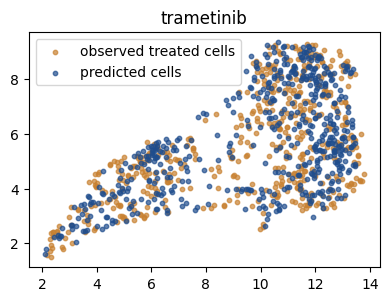

In [6]:
drug = "trametinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = AOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=5000, batch_size=4096, lr=5e-3, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, median_gamma)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('test_map') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/aot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2631, 48)
(2104, 48)
(527, 48)
(2104, 48)
(527, 48)
Median heuristic gamma: 0.05748945574198288
**************** Run: 0 ****************
Epoch 0 | Train Loss 47998.9102 | Train MMD 0.0948 | Test MMD 0.0941 
Epoch 500 | Train Loss 28724.5039 | Train MMD 0.0089 | Test MMD 0.0065 
Epoch 1000 | Train Loss 28531.4766 | Train MMD 0.0087 | Test MMD 0.0063 
Epoch 1500 | Train Loss 28512.0605 | Train MMD 0.0087 | Test MMD 0.0063 
Epoch 2000 | Train Loss 28509.3203 | Train MMD 0.0087 | Test MMD 0.0063 
Epoch 2500 | Train Loss 28508.5527 | Train MMD 0.0087 | Test MMD 0.0063 
Epoch 3000 | Train Loss 28507.7480 | Train MMD 0.0087 | Test MMD 0.0063 
Epoch 3500 | Train Loss 28507.5879 | Train MMD 0.0088 | Test MMD 0.0064 
Epoch 4000 | Train Loss 28507.9551 | Train MMD 0.0087 | Test MMD 0.0063 
Epoch 4500 | Train Loss 28507.6816 | Train MMD 0.0087 | Test MMD 0.0063 
Epoch 5000 | Train Loss 28507.6816 | Train MMD 0.0087 | Test MMD 0.0063 
Test MMD: 0.0063
Test Wa

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

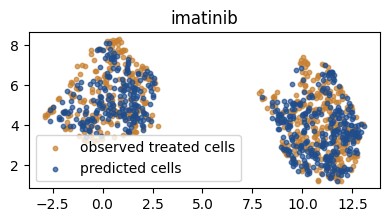

In [7]:
drug = "imatinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = AOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=5000, batch_size=4096, lr=5e-3, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, median_gamma)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('test_map') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/aot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2693, 48)
(2154, 48)
(539, 48)
(2154, 48)
(539, 48)
Median heuristic gamma: 0.07603466947967093
**************** Run: 0 ****************
Epoch 0 | Train Loss 42504.0664 | Train MMD 0.0084 | Test MMD 0.0092 


Epoch 500 | Train Loss 29381.8867 | Train MMD 0.0083 | Test MMD 0.0088 
Epoch 1000 | Train Loss 29051.7500 | Train MMD 0.0078 | Test MMD 0.0083 
Epoch 1500 | Train Loss 29012.8555 | Train MMD 0.0077 | Test MMD 0.0081 
Epoch 2000 | Train Loss 29006.1445 | Train MMD 0.0076 | Test MMD 0.0080 
Epoch 2500 | Train Loss 29003.8574 | Train MMD 0.0076 | Test MMD 0.0080 
Epoch 3000 | Train Loss 29004.3301 | Train MMD 0.0076 | Test MMD 0.0080 
Epoch 3500 | Train Loss 29005.0645 | Train MMD 0.0075 | Test MMD 0.0079 
Epoch 4000 | Train Loss 29004.1074 | Train MMD 0.0076 | Test MMD 0.0080 
Epoch 4500 | Train Loss 29004.6523 | Train MMD 0.0076 | Test MMD 0.0080 
Epoch 5000 | Train Loss 29004.2012 | Train MMD 0.0076 | Test MMD 0.0080 
Test MMD: 0.0080
Test Wasserstein: 1.7975
                        mean  std
mmd2_gamma_median     0.0080  NaN
mmd2_gamma_0.5        0.0130  NaN
mmd2_gamma_1.0        0.0082  NaN
wasserstein_distance  1.7975  NaN
R2_feature_means      0.8808  NaN


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

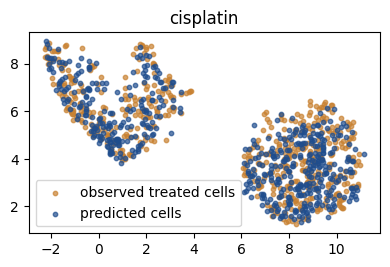

In [8]:
drug = "cisplatin"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = AOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=5000, batch_size=4096, lr=5e-3, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, median_gamma)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('test_map') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/aot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2796, 48)
(2236, 48)
(560, 48)
(2236, 48)
(560, 48)
Median heuristic gamma: 0.074449069228528
**************** Run: 0 ****************
Epoch 0 | Train Loss 53271.4180 | Train MMD 0.0306 | Test MMD 0.0283 
Epoch 500 | Train Loss 34218.8516 | Train MMD 0.0116 | Test MMD 0.0100 
Epoch 1000 | Train Loss 32645.5195 | Train MMD 0.0101 | Test MMD 0.0085 
Epoch 1500 | Train Loss 32097.4922 | Train MMD 0.0097 | Test MMD 0.0081 
Epoch 2000 | Train Loss 31813.9668 | Train MMD 0.0092 | Test MMD 0.0077 
Epoch 2500 | Train Loss 31690.9043 | Train MMD 0.0090 | Test MMD 0.0074 
Epoch 3000 | Train Loss 31589.6816 | Train MMD 0.0089 | Test MMD 0.0074 
Epoch 3500 | Train Loss 31513.8496 | Train MMD 0.0088 | Test MMD 0.0072 
Epoch 4000 | Train Loss 31490.1973 | Train MMD 0.0087 | Test MMD 0.0072 
Epoch 4500 | Train Loss 31486.5254 | Train MMD 0.0087 | Test MMD 0.0072 
Epoch 5000 | Train Loss 31485.4961 | Train MMD 0.0087 | Test MMD 0.0071 
Test MMD: 0.0071
Test Wass

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

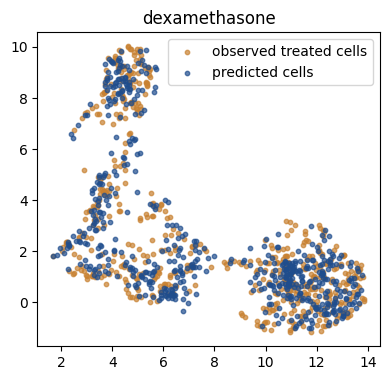

In [7]:
drug = "dexamethasone"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = AOT(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=5000, batch_size=4096, lr=1e-3, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post, median_gamma)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('test_map') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/aot_on_4i_drug_{drug}.png", dpi=300)